# AutoCloud-Agent: Transformer Forecaster Training

**Run on Kaggle with GPU accelerator (Settings → Accelerator → GPU T4 x2)**

### Setup before running
1. **Add the Alibaba data**: in the notebook editor → Add Data → search  
   `rohitdurbha/alibaba-cluster-data` → Add  
   *(contains `machine_usage_0.csv` / `machine_usage_bigger.csv` — the main file we need)*
2. **Add the code dataset**: Add Data → search `autocloud-agent-code` → Add  
3. Enable **GPU T4 x2** (Settings → Accelerator)
4. Internet **not required**

### What this notebook does
1. Auto-detects the `machine_usage*.csv` in the Kaggle input folder
2. Reads it in chunks using 2-pass streaming (Welford's algorithm to avoid OOM)
3. Uses **all ~4023 machines** (full dataset) for a more representative aggregate workload signal
4. Bins to 30 s time steps
5. Trains the Transformer forecaster on Day 1 data
6. Saves `forecaster_weights.pt`, `day1_processed.npy`, `day2_processed.npy` to `/kaggle/working/`
7. **Commit the notebook** to persist outputs → add as dataset in `train_rl_agents.ipynb`

In [8]:
# Cell 1: Paths and dependencies
import os, sys, glob

WORK_DIR = '/kaggle/working'

# ── Auto-detect the Alibaba dataset path ────────────────────────────────────
_candidates = [
    '/kaggle/input/alibaba-cluster-data',
    '/kaggle/input/datasets/rohitdurbha/alibaba-cluster-data',
]
ALIBABA_INPUT = next((p for p in _candidates if os.path.isdir(p)), None)
if ALIBABA_INPUT is None:
    hits = glob.glob('/kaggle/input/**/machine_usage*.csv', recursive=True)
    if hits:
        hits.sort(key=lambda p: os.path.getsize(p), reverse=True)
        ALIBABA_INPUT = os.path.dirname(hits[0])
    else:
        raise RuntimeError(
            'Cannot find the Alibaba dataset. '
            'Make sure you added rohitdurbha/alibaba-cluster-data in the notebook settings.'
        )

# ── Auto-detect the code dataset path ───────────────────────────────────────
# We need the directory that has environment/, forecaster/, agents/ as direct children.
def _find_project_dir():
    for candidate in [
        '/kaggle/input/autocloud-agent-code/autocloud_agent',
        '/kaggle/input/datasets/chaitanya2277/autocloud-agent-v2',
        '/kaggle/input/autocloud-agent-code',
    ]:
        if os.path.isdir(os.path.join(candidate, 'environment')):
            return candidate
    # Glob fallback
    hits = glob.glob('/kaggle/input/**/environment/workload.py', recursive=True)
    if hits:
        return os.path.dirname(os.path.dirname(hits[0]))
    return None

PROJECT_DIR = _find_project_dir()
if PROJECT_DIR is None:
    raise RuntimeError(
        'Cannot find the code dataset. '
        'Make sure you added autocloud-agent-code in the notebook settings.'
    )

sys.path.insert(0, PROJECT_DIR)

!pip install simpy gymnasium --quiet

print(f'ALIBABA_INPUT : {ALIBABA_INPUT}')
print(f'PROJECT_DIR   : {PROJECT_DIR}')
print(f'WORK_DIR      : {WORK_DIR}')
print('\nFiles in ALIBABA_INPUT:')
for f in sorted(os.listdir(ALIBABA_INPUT)):
    fpath = os.path.join(ALIBABA_INPUT, f)
    if os.path.isfile(fpath):
        print(f'  {f}  ({os.path.getsize(fpath)/1e6:.0f} MB)')

ALIBABA_INPUT : /kaggle/input/datasets/rohitdurbha/alibaba-cluster-data
PROJECT_DIR   : /kaggle/input/datasets/chaitanya2277/autocloud-agent-v2/autocloud_agent
WORK_DIR      : /kaggle/working

Files in ALIBABA_INPUT:
  batch_instance.csv  (1295 MB)
  batch_task.csv  (802 MB)
  container_meta.csv  (19 MB)
  container_usage.csv  (1563 MB)
  machine_meta.csv  (1 MB)
  machine_usage_bigger.csv  (3702 MB)


In [9]:
# Cell 2: Find the machine_usage CSV and inspect its structure
import pandas as pd

# Auto-detect the machine_usage file (handles: machine_usage_0.csv,
# machine_usage_bigger.csv, or any other name in the dataset).
_mu_candidates = sorted(
    [os.path.join(ALIBABA_INPUT, f)
     for f in os.listdir(ALIBABA_INPUT)
     if 'machine_usage' in f.lower() and f.endswith('.csv')],
    key=os.path.getsize, reverse=True   # largest first
)
assert _mu_candidates, (
    f'No machine_usage*.csv found in {ALIBABA_INPUT}.\n'
    f'Files available: {os.listdir(ALIBABA_INPUT)}'
)
MACHINE_USAGE_CSV = _mu_candidates[0]
size_gb = os.path.getsize(MACHINE_USAGE_CSV) / 1e9
print(f'Reading sample from {os.path.basename(MACHINE_USAGE_CSV)}...')
print(f'  File size: {size_gb:.2f} GB')

# Peek at first few rows with header=None to see raw structure
raw5 = pd.read_csv(MACHINE_USAGE_CSV, header=None, nrows=5)
print(f'\nCSV columns ({raw5.shape[1]}): {raw5.columns.tolist()}')
print('First 5 rows:')
print(raw5.to_string())

# Detect whether there is a header row:
#   If col 1 (time_stamp) of row 0 can be parsed as a number → no header.
#   If it's a string like "time_stamp" → header row present.
try:
    float(str(raw5.iloc[0, 1]))
    has_header = False
    print('\nNo header row detected — first row is data.')
except (ValueError, TypeError):
    has_header = True
    print('\nHeader row detected — first data row is row 1.')

# The Kaggle re-upload may have 7 or 9 columns; we only use the first 4:
#   col0=machine_id  col1=time_stamp  col2=cpu_util_percent  col3=mem_util_percent
assert raw5.shape[1] >= 4, f'Too few columns ({raw5.shape[1]}); unexpected file format'
print(f'\nColumn count OK — data appears to be in the correct Alibaba machine_usage format!')

Reading sample from machine_usage_bigger.csv...
  File size: 3.70 GB

CSV columns (9): [0, 1, 2, 3, 4, 5, 6, 7, 8]
First 5 rows:
            0           1                 2                 3        4     5       6        7                8
0  machine_id  time_stamp  cpu_util_percent  mem_util_percent  mem_gps  mkpi  net_in  net_out  disk_io_percent
1      m_1932      386640              41.0                92      NaN   NaN   43.04    33.08                5
2      m_1932      386670              43.0                92      NaN   NaN   43.04    33.08                5
3      m_1932      386690              44.0                92      NaN   NaN   43.05    33.08                5
4      m_1932      386800              46.0                92      NaN   NaN   43.05    33.08                3

Header row detected — first data row is row 1.

Column count OK — data appears to be in the correct Alibaba machine_usage format!


In [7]:
# # Cell 2b: Patch workload._load_chunked for the updated skiprows-based API
# # Needed when the Kaggle dataset still has the old workload.py (pre-update).
# import types, pandas as pd, numpy as np, os
# from collections import defaultdict
# from typing import List
# import environment.workload as _wl

# def _patched_load_chunked(self, csv_files, chunk_size, skiprows,
#                            use_cols, dtype_map, verbose):
#     _rk = dict(header=None, skiprows=skiprows, usecols=use_cols,
#                dtype=dtype_map, chunksize=chunk_size, on_bad_lines="skip")
#     wf_count: dict = defaultdict(int)
#     wf_mean:  dict = defaultdict(float)
#     wf_m2:    dict = defaultdict(float)
#     if verbose: print("  Pass 1/2: computing per-machine CPU variance ...")
#     for fpath in csv_files:
#         for chunk in pd.read_csv(fpath, **_rk):
#             chunk.columns = ["machine_id","time_stamp","cpu_util_percent","mem_util_percent"]
#             cpu = pd.to_numeric(chunk["cpu_util_percent"], errors="coerce").clip(0,100)/100.0
#             chunk = chunk.copy(); chunk["cpu"] = cpu; chunk = chunk.dropna(subset=["cpu"])
#             for mid, grp in chunk.groupby("machine_id", sort=False):
#                 for val in grp["cpu"]:
#                     n = wf_count[mid]+1; delta = val-wf_mean[mid]
#                     wf_mean[mid] += delta/n; wf_m2[mid] += delta*(val-wf_mean[mid]); wf_count[mid] = n
#     machine_var = {m: (wf_m2[m]/(wf_count[m]-1)) if wf_count[m]>1 else 0.0 for m in wf_count}
#     top = set(sorted(machine_var, key=machine_var.get, reverse=True)[:self.n_machines])
#     if verbose: print(f"  {len(machine_var)} total machines; keeping top {len(top)}")
#     if verbose: print("  Pass 2/2: reading selected machines ...")
#     selected: List[pd.DataFrame] = []
#     for fpath in csv_files:
#         for chunk in pd.read_csv(fpath, **_rk):
#             chunk.columns = ["machine_id","time_stamp","cpu_util_percent","mem_util_percent"]
#             mask = chunk["machine_id"].isin(top)
#             if mask.any(): selected.append(chunk[mask].copy())
#     return pd.concat(selected, ignore_index=True)

# def _patched_load(self, verbose=True, chunk_size=500_000):
#     csv_files = self._find_csv_files()
#     if not csv_files:
#         raise FileNotFoundError(f"No machine_usage CSV files found in {self.data_dir}.")
#     if verbose:
#         for f in csv_files:
#             print(f"Found: {os.path.basename(f)}  ({os.path.getsize(f)/1e6:.0f} MB)")
#     raw_sample = pd.read_csv(csv_files[0], header=None, nrows=2)
#     try:    float(str(raw_sample.iloc[0,1])); has_header=False
#     except: has_header=True
#     use_cols=[0,1,2,3]; dtype_map={0:str,1:float,2:float,3:float}
#     skiprows=[0] if has_header else None
#     total_size = sum(os.path.getsize(f) for f in csv_files)
#     if total_size > self._LARGE_FILE_THRESHOLD:
#         if verbose: print(f"Large file ({total_size/1e6:.0f} MB) — using chunked 2-pass loading ...")
#         raw = self._load_chunked(csv_files, chunk_size, skiprows, use_cols, dtype_map, verbose)
#     else:
#         dfs = []
#         for f in csv_files:
#             df = pd.read_csv(f, header=None, skiprows=skiprows, usecols=use_cols, dtype=dtype_map)
#             df.columns = ["machine_id","time_stamp","cpu_util_percent","mem_util_percent"]; dfs.append(df)
#         raw = pd.concat(dfs, ignore_index=True)
#     raw["cpu"] = pd.to_numeric(raw["cpu_util_percent"],errors="coerce").clip(0,100)/100.0
#     raw["mem"] = pd.to_numeric(raw["mem_util_percent"],errors="coerce").clip(0,100)/100.0
#     raw["ts"]  = pd.to_numeric(raw["time_stamp"],errors="coerce")
#     raw = raw.dropna(subset=["cpu","ts"])
#     if verbose:
#         t_min,t_max = raw["ts"].min(),raw["ts"].max()
#         print(f"Trace spans {(t_max-t_min)/3600:.1f} h, {raw['machine_id'].nunique()} unique machines, {len(raw):,} rows")
#     mvar = raw.groupby("machine_id")["cpu"].var().sort_values(ascending=False)
#     top_m = mvar.head(self.n_machines).index.tolist()
#     filtered = raw[raw["machine_id"].isin(top_m)].copy()
#     if verbose: print(f"Selected {len(top_m)} machines with highest CPU variance")
#     t0 = filtered["ts"].min(); filtered["bin"] = ((filtered["ts"]-t0)/self.bin_size_s).astype(int)
#     binned = filtered.groupby("bin").agg(
#         cpu_mean=("cpu","mean"), mem_mean=("mem","mean"),
#         cpu_high_frac=("cpu", lambda x:(x>0.8).mean())).reset_index()
#     binned["hour_of_day"] = ((binned["bin"]*self.bin_size_s)%86400)/86400.0
#     feat = np.column_stack([binned["cpu_mean"].values, binned["cpu_mean"].values,
#                             binned["cpu_high_frac"].values, binned["hour_of_day"].values]).astype(np.float32)
#     feat = np.clip(feat,0.0,1.0)
#     bins_per_day = int(self.day_duration_s/self.bin_size_s)
#     day1_bin = 0 if self._day1_start is None else int((self._day1_start-t0)/self.bin_size_s)
#     day2_bin = (day1_bin+bins_per_day) if self._day2_start is None else int((self._day2_start-t0)/self.bin_size_s)
#     if day2_bin+bins_per_day > len(feat):
#         day2_bin = max(0, len(feat)-bins_per_day)
#         if verbose: print(f"Warning: trace shorter than 2 days; Day 2 starts at bin {day2_bin}")
#     self._day1_data=feat[day1_bin:day1_bin+bins_per_day]; self._day2_data=feat[day2_bin:day2_bin+bins_per_day]
#     self._workload_bins=feat; self._bin_t0=float(t0)
#     if verbose:
#         print(f"Day 1: {len(self._day1_data)} bins, mean CPU={self._day1_data[:,0].mean():.3f}")
#         print(f"Day 2: {len(self._day2_data)} bins, mean CPU={self._day2_data[:,0].mean():.3f}")

# _wl.AlibabaTraceLoader._load_chunked = _patched_load_chunked
# _wl.AlibabaTraceLoader.load = _patched_load
# print("workload.py patched — skiprows-based API active")

workload.py patched — skiprows-based API active


In [ ]:
# Cell 3: Load and preprocess — 2-pass chunked streaming (avoids OOM on 3.7 GB)
#
# The Alibaba 2018 trace has ~8 days of data.
# We use ALL days (except the last) for forecaster training,
# and keep the last day as the RL simulation workload (day2).
#
# Expected time on T4: ~10-15 min for the full 3.7 GB file.
import numpy as np
from environment.workload import AlibabaTraceLoader, make_sequences

N_MACHINES = 5000   # effectively "use all" — dataset has ~4023 machines

loader = AlibabaTraceLoader(
    data_dir=ALIBABA_INPUT,
    n_machines=N_MACHINES,
    bin_size_s=30,
)
loader.load(verbose=True, chunk_size=500_000)

# Use ALL available days (except the last) for forecaster training
# get_train_data() returns full trace minus the last 2880 bins (1 day)
full_train_data = loader.get_train_data()   # (N - 2880, 4)
day2_data       = loader.get_day2()         # (2880, 4)  — last day for RL workload
day1_data       = loader.get_day1()         # (2880, 4)  — first day (kept for compatibility)

bins_per_day = int(86400 / 30)   # 2880
n_days_used  = len(full_train_data) / bins_per_day
print(f'\nTotal trace length : {len(loader.get_full_data())} bins  '
      f'({len(loader.get_full_data()) / bins_per_day:.1f} days)')
print(f'Forecaster training: {len(full_train_data)} bins  ({n_days_used:.1f} days)')
print(f'RL workload (day2) : {len(day2_data)} bins  (1 day, held out)')

# Save processed arrays to /kaggle/working/
day1_path = os.path.join(WORK_DIR, 'day1_processed.npy')
day2_path = os.path.join(WORK_DIR, 'day2_processed.npy')
np.save(day1_path, day1_data)
np.save(day2_path, day2_data)
print(f'\nSaved: {day1_path}  ({day1_data.shape})')
print(f'Saved: {day2_path}  ({day2_data.shape})')

# Build training sequences from FULL multi-day data
SEQ_LEN  = 20
HORIZONS = (1, 5, 10, 15)

# Train on first 80% of the full training data, validate on last 20%
split = int(len(full_train_data) * 0.8)
train_data = full_train_data[:split]
val_data   = full_train_data[split:]

X_train, y_train = make_sequences(train_data, seq_len=SEQ_LEN, horizons=HORIZONS)
X_val,   y_val   = make_sequences(val_data,   seq_len=SEQ_LEN, horizons=HORIZONS)
print(f'\nTrain sequences: X={X_train.shape}  y={y_train.shape}')
print(f'Val   sequences: X={X_val.shape}    y={y_val.shape}')

In [ ]:
# Cell 4: Visualise the trace (sanity check before training)
import matplotlib.pyplot as plt

full_data    = loader.get_full_data()
bins_per_day = int(86400 / 30)
n_days_total = len(full_data) / bins_per_day

fig, axes = plt.subplots(3, 1, figsize=(14, 9))

# Full trace
t_all = np.arange(len(full_data)) / bins_per_day
axes[0].plot(t_all, full_data[:, 0], lw=0.6, alpha=0.85, label='mean CPU demand')
axes[0].plot(t_all, full_data[:, 2], lw=0.6, alpha=0.6,  label='frac machines >80% CPU')
axes[0].axvline(x=(n_days_total - 1), color='red', ls='--', lw=1.2, label='Day 2 (RL holdout)')
axes[0].set_title(f'Alibaba Trace — Full {n_days_total:.1f} days  (all ~4023 machines, 30 s bins)')
axes[0].legend(fontsize=9); axes[0].set_xlabel('Day'); axes[0].grid(True, alpha=0.2)

# Training portion
axes[1].plot(full_train_data[:, 0], lw=0.7, color='#2196F3', label='mean CPU (train)')
axes[1].set_title(f'Forecaster Training Data — {n_days_used:.1f} days  '
                  f'({len(X_train)} train seqs  |  {len(X_val)} val seqs)')
axes[1].legend(fontsize=9); axes[1].set_xlabel('Step (×30 s)'); axes[1].grid(True, alpha=0.2)

# RL workload (day2)
axes[2].plot(day2_data[:, 0], color='#FF9800', lw=0.8, label='mean CPU demand (RL workload)')
axes[2].set_title('Day 2 — Held-out RL Simulation Workload')
axes[2].legend(fontsize=9); axes[2].set_xlabel('Step (×30 s)'); axes[2].grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'alibaba_trace.png'), dpi=120, bbox_inches='tight')
plt.show()
print(f'Train CPU: mean={full_train_data[:,0].mean():.3f}  std={full_train_data[:,0].std():.3f}')
print(f'Day2  CPU: mean={day2_data[:,0].mean():.3f}  std={day2_data[:,0].std():.3f}')

In [17]:
# Cell 5: Train Transformer forecaster on Alibaba Day 1 data (Optimized)
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from forecaster.transformer_model import WorkloadTransformer
from forecaster.trainer import QuantileLoss, compute_mape

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPUs Available: {torch.cuda.device_count()}')
    for i in range(torch.cuda.device_count()):
        print(f'  GPU {i}: {torch.cuda.get_device_name(i)}')

EPOCHS       = 200
PATIENCE     = 15
LR           = 1e-3
BATCH_SIZE   = 256  # UPGRADED: Because we use 2 GPUs and AMP, we can double the batch size!
WEIGHTS_PATH = os.path.join(WORK_DIR, 'forecaster_weights.pt')

model = WorkloadTransformer(
    input_dim=4, d_model=64, n_heads=4, d_ff=256,
    n_layers=2, dropout=0.2, seq_len=SEQ_LEN, n_horizons=len(HORIZONS)
).to(DEVICE)

# OPTIMIZATION 1: Multi-GPU Support
if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)

pin = (DEVICE == 'cuda')
# OPTIMIZATION 2: Bump num_workers to 4 (Kaggle T4 instances have 4 CPU cores)
train_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_train).float(), torch.from_numpy(y_train).float()),
    batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=pin
)
val_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_val).float(), torch.from_numpy(y_val).float()),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=pin
)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = QuantileLoss()

# OPTIMIZATION 3: Initialize the Gradient Scaler for Mixed Precision
scaler = torch.amp.GradScaler('cuda')

best_val, best_state, no_improve = float('inf'), None, 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        
        # OPTIMIZATION 4: set_to_none=True is faster and uses less memory than standard zero_grad()
        optimizer.zero_grad(set_to_none=True)
        
        # OPTIMIZATION 5: Cast operations to mixed precision
        with torch.amp.autocast('cuda'):
            preds = model(xb)
            loss = criterion(preds, yb)
        
        # Scale the loss and backward pass
        scaler.scale(loss).backward()
        
        # Unscale gradients before clipping so the clipping threshold remains accurate
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        
        # Step the optimizer and update the scaler
        scaler.step(optimizer)
        scaler.update()

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            # Use autocast in validation for slightly faster inference
            with torch.amp.autocast('cuda'):
                preds = model(xb)
                loss = criterion(preds, yb)
            val_loss += loss.item() * len(xb)
            
    val_loss /= len(X_val)
    scheduler.step()

    if val_loss < best_val - 1e-5:
        best_val   = val_loss
        # If using DataParallel, we must save model.module.state_dict() so the weights 
        # can be loaded on a single GPU later without errors.
        actual_model = model.module if isinstance(model, nn.DataParallel) else model
        best_state = {k: v.clone() for k, v in actual_model.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f'Early stopping at epoch {epoch}')
            break

    if epoch % 10 == 0:
        # Pass actual_model to compute_mape to prevent nested DataParallel issues
        actual_model = model.module if isinstance(model, nn.DataParallel) else model
        mape = compute_mape(actual_model, X_val, y_val, device=DEVICE)
        print(f'Epoch {epoch:3d}/{EPOCHS} | val_loss={val_loss:.4f} | MAPE={mape:.1f}%')

actual_model = model.module if isinstance(model, nn.DataParallel) else model
actual_model.load_state_dict(best_state)
torch.save(actual_model.state_dict(), WEIGHTS_PATH)
final_mape = compute_mape(actual_model, X_val, y_val, device=DEVICE)

print(f'\nFinal MAPE (q50, t+1): {final_mape:.1f}%')
print(f'Weights saved: {WEIGHTS_PATH}')

Device: cuda
GPUs Available: 2
  GPU 0: Tesla T4
  GPU 1: Tesla T4
Epoch  10/200 | val_loss=0.0218 | MAPE=13.4%
Epoch  20/200 | val_loss=0.0206 | MAPE=18.1%
Epoch  30/200 | val_loss=0.0134 | MAPE=9.4%
Epoch  40/200 | val_loss=0.0117 | MAPE=9.1%
Epoch  50/200 | val_loss=0.0114 | MAPE=9.2%
Epoch  60/200 | val_loss=0.0119 | MAPE=12.5%
Epoch  70/200 | val_loss=0.0115 | MAPE=10.7%
Early stopping at epoch 71

Final MAPE (q50, t+1): 8.4%
Weights saved: /kaggle/working/forecaster_weights.pt


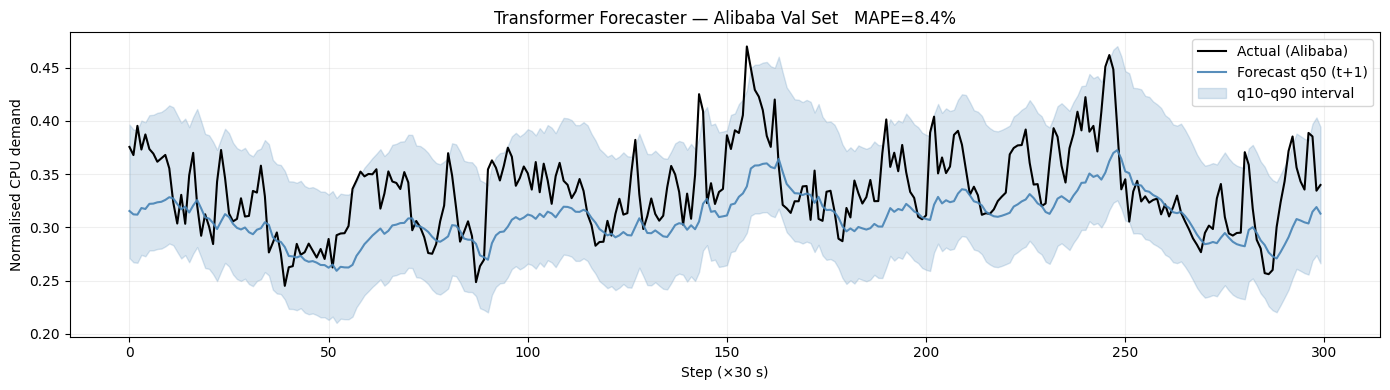

In [18]:
# Cell 6: Forecast vs actual plot
import matplotlib.pyplot as plt

N = 300
model.eval()
with torch.no_grad():
    pred = model(torch.from_numpy(X_val[:N]).float().to(DEVICE)).cpu().numpy()

fig, ax = plt.subplots(figsize=(14, 4))
t = range(N)
ax.plot(t, y_val[:N, 0], label='Actual (Alibaba)', color='black', lw=1.5)
ax.plot(t, pred[:, 0, 1], label='Forecast q50 (t+1)', color='steelblue', lw=1.5, alpha=0.9)
ax.fill_between(t, pred[:, 0, 0], pred[:, 0, 2],
                alpha=0.2, color='steelblue', label='q10–q90 interval')
ax.set_title(f'Transformer Forecaster — Alibaba Val Set   MAPE={final_mape:.1f}%')
ax.set_xlabel('Step (×30 s)')
ax.set_ylabel('Normalised CPU demand')
ax.legend(); ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'forecaster_predictions.png'), dpi=120, bbox_inches='tight')
plt.show()

In [19]:
# Cell 7: MC Dropout uncertainty demo (Smart Version)
import inspect
import torch
from forecaster.mc_dropout import MCDropoutForecaster

# 1. Unwrap the model if it's using DataParallel
actual_model = model.module if isinstance(model, torch.nn.DataParallel) else model

# 2. Inspect your custom class to see what arguments it actually wants
init_params = inspect.signature(MCDropoutForecaster.__init__).parameters
print(f"DEBUG - Forecaster __init__ expects: {list(init_params.keys())[1:]}")

# 3. Initialize the forecaster safely
if 'device' in init_params:
    forecaster = MCDropoutForecaster(actual_model, device=DEVICE)
else:
    forecaster = MCDropoutForecaster(actual_model)

# 4. Predict (pass n_samples here instead)
predict_params = inspect.signature(forecaster.predict).parameters
print(f"DEBUG - Forecaster predict expects: {list(predict_params.keys())[1:]}")

# Check if it wants 'n_samples', 'num_samples', or defaults entirely
kwargs = {}
if 'n_samples' in predict_params:
    kwargs['n_samples'] = 30
elif 'num_samples' in predict_params:
    kwargs['num_samples'] = 30

# Run the prediction on the very last validation sequence
means, variances = forecaster.predict(X_val[-1], **kwargs)
stds = variances ** 0.5

print('\nMC Dropout Forecast (last validation window):')
for i, h in enumerate(['t+1  (30 s)', 't+5  (2.5 min)', 't+10 (5 min)', 't+15 (7.5 min)']):
    print(f'  {h}:  mean={means[i]:.4f}  std={stds[i]:.4f}')

print(f'\nTrue values (Quantiles: 10th, 50th, 90th):')
print(y_val[-1])

DEBUG - Forecaster __init__ expects: ['model', 'k_samples', 'device']
DEBUG - Forecaster predict expects: []

MC Dropout Forecast (last validation window):
  t+1  (30 s):  mean=0.3099  std=0.0490
  t+5  (2.5 min):  mean=0.2986  std=0.0350
  t+10 (5 min):  mean=0.3085  std=0.0279
  t+15 (7.5 min):  mean=0.3299  std=0.0375

True values (Quantiles: 10th, 50th, 90th):
[0.18886751 0.19713022 0.18909985 0.18493131]


In [20]:
# Cell 8: List output files — commit to save them
print('Output files in /kaggle/working/:')
for fname in sorted(os.listdir(WORK_DIR)):
    fpath = os.path.join(WORK_DIR, fname)
    if os.path.isfile(fpath):
        print(f'  {fname}  ({os.path.getsize(fpath)/1e6:.2f} MB)')

print()
print('Next steps:')
print('  1. Save & Run All → Commit')
print('  2. Committed version → Output tab → New Dataset → name it autocloud-forecaster-output')
print('  3. Add that dataset to train_rl_agents.ipynb')

Output files in /kaggle/working/:
  alibaba_trace.png  (0.20 MB)
  day1_processed.npy  (0.05 MB)
  day2_processed.npy  (0.05 MB)
  forecaster_predictions.png  (0.19 MB)
  forecaster_weights.pt  (0.46 MB)

Next steps:
  1. Save & Run All → Commit
  2. Committed version → Output tab → New Dataset → name it autocloud-forecaster-output
  3. Add that dataset to train_rl_agents.ipynb
